<a href="https://colab.research.google.com/github/Venkata-Prabhath/EDA_-23BDS0168-_Venkata_Prabhath/blob/main/Venkata_Prabhath_23BDS0168_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cell 1: Import Libraries & Load Data**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline
sns.set_style("whitegrid")

# Load Dataset directly
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/CreditCard.csv"
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,rownames,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,2,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,3,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,4,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,5,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


# **Cell 2: Initial Data Inspection**

In [ ]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types & Info
print("\nDataset Info:")
df.info()

# Statistical summary for numerical columns
display(df.describe())

# Statistical summary for categorical columns
display(df.describe(include='object'))

Shape: (1319, 13)

Columns:
Index(['rownames', 'card', 'reports', 'age', 'income', 'share', 'expenditure',
       'owner', 'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     1319 non-null   int64  
 1   card         1319 non-null   object 
 2   reports      1319 non-null   int64  
 3   age          1319 non-null   float64
 4   income       1319 non-null   float64
 5   share        1319 non-null   float64
 6   expenditure  1319 non-null   float64
 7   owner        1319 non-null   object 
 8   selfemp      1319 non-null   object 
 9   dependents   1319 non-null   int64  
 10  months       1319 non-null   int64  
 11  majorcards   1319 non-null   int64  
 12  active       1319 non-null   int64  
dtypes: float64(4), int64(6), object(3)
mem

,rownames,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,660.000000,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,380.906813,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,1.000000,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,330.500000,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,660.000000,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,989.500000,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,1319.000000,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


,card,owner,selfemp
count,1319,1319,1319
unique,2,2,2
top,yes,no,no
freq,1023,738,1228


# **Cell 3: Missing Values & Duplicates Analysis**

Missing Values per Column:
 rownames       0
card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
dtype: int64


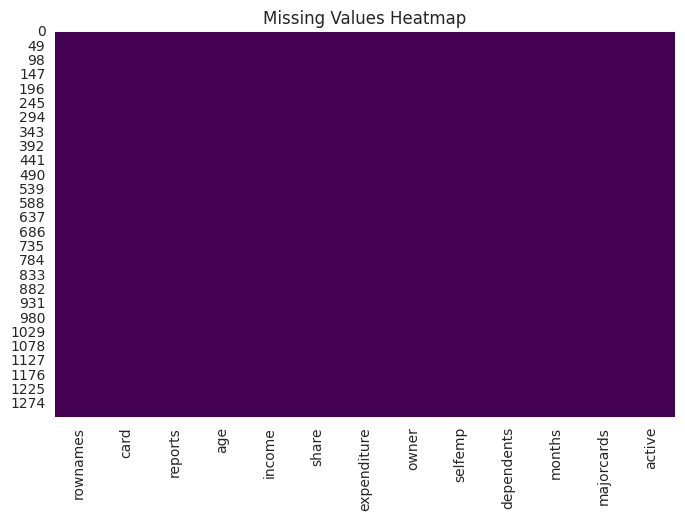

Duplicate Rows: 0
Shape after removing duplicates: (1319, 13)


In [ ]:
# Check missing values
print("Missing Values per Column:\n", df.isnull().sum())

# Visualize missing values heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Check and remove duplicates
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

# **Cell 4: Handling Missing Values**

In [ ]:
# Fill numerical columns with mean
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing values remain
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 rownames       0
card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
dtype: int64


# **Cell 5: Data Transformation (Binning & Encoding)**

In [ ]:
# Example of Binning (e.g., binning a numerical feature like balance or limit if present)
# Let's dynamically pick the first available major numeric column or use a fallback.
target_num_col = num_cols[0] if len(num_cols) > 0 else None

if target_num_col:
    df['Feature_Category'] = pd.cut(
        df[target_num_col],
        bins=3,
        labels=['Low', 'Medium', 'High']
    )
    display(df[[target_num_col, 'Feature_Category']].head())

# Example of Encoding categorical features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

if len(cat_cols) > 0:
    encoded_col = cat_cols[0]
    df[f'{encoded_col}_encoded'] = le.fit_transform(df[encoded_col].astype(str))
    display(df[[encoded_col, f'{encoded_col}_encoded']].head())

,rownames,Feature_Category
0,1,Low
1,2,Low
2,3,Low
3,4,Low
4,5,Low


,card,card_encoded
0,yes,1
1,yes,1
2,yes,1
3,yes,1
4,yes,1


# **Cell 6: Univariate Analysis**

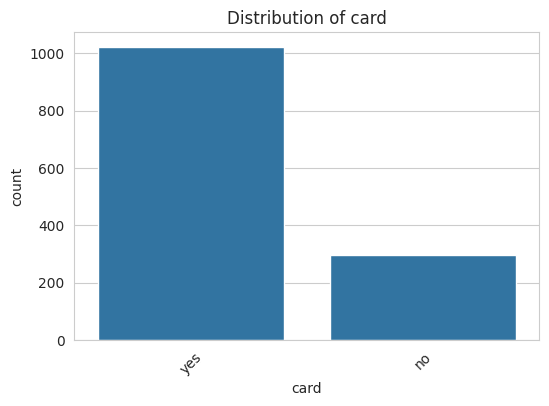

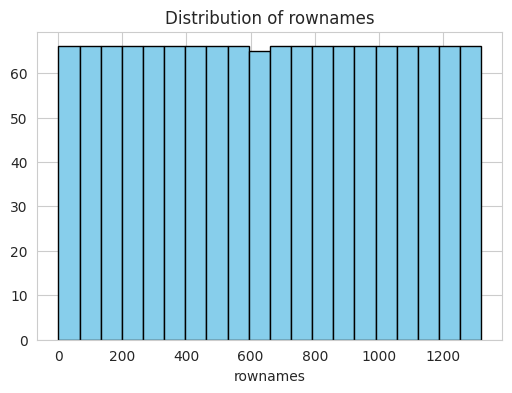

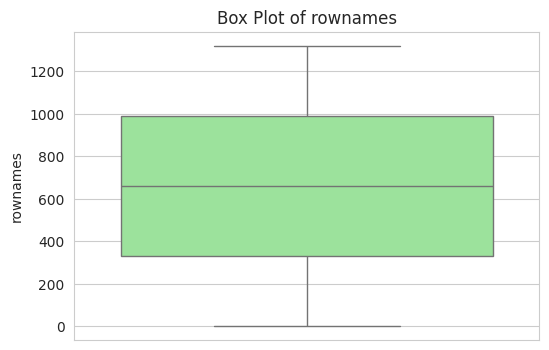

In [ ]:
# 1. Count Plot (for a categorical variable if available)
if len(cat_cols) > 0:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=cat_cols[0], data=df)
    plt.title(f"Distribution of {cat_cols[0]}")
    plt.xticks(rotation=45)
    plt.show()

# 2. Histogram (for a numerical variable)
if target_num_col:
    plt.figure(figsize=(6, 4))
    plt.hist(df[target_num_col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {target_num_col}")
    plt.xlabel(target_num_col)
    plt.show()

# 3. Box Plot (for outlier check)
if target_num_col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[target_num_col], color='lightgreen')
    plt.title(f"Box Plot of {target_num_col}")
    plt.show()

# **Cell 7: Bivariate & Multivariate Analysis**

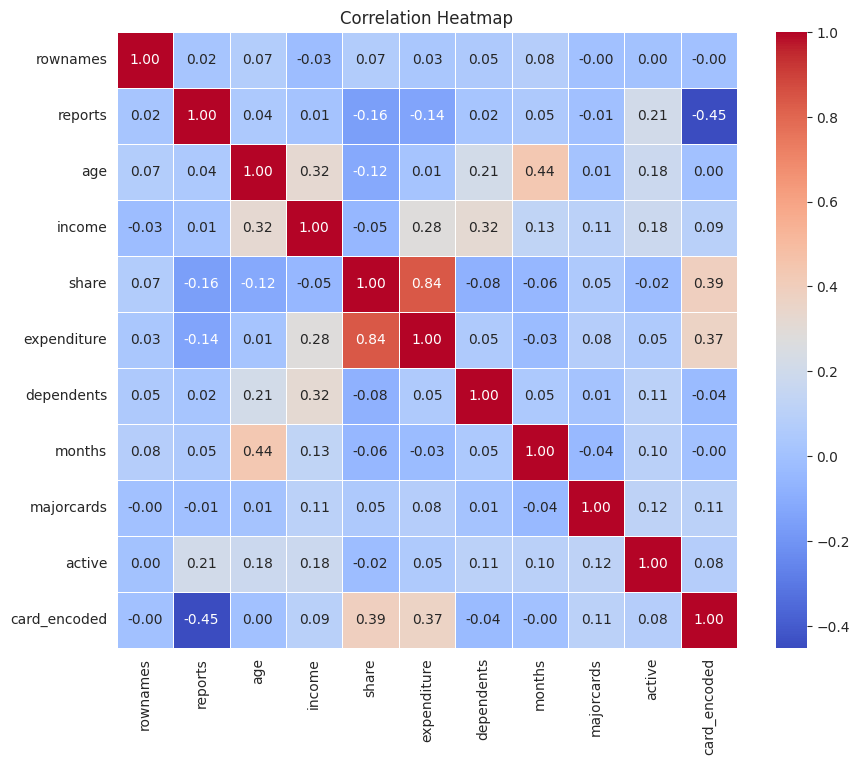

In [ ]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

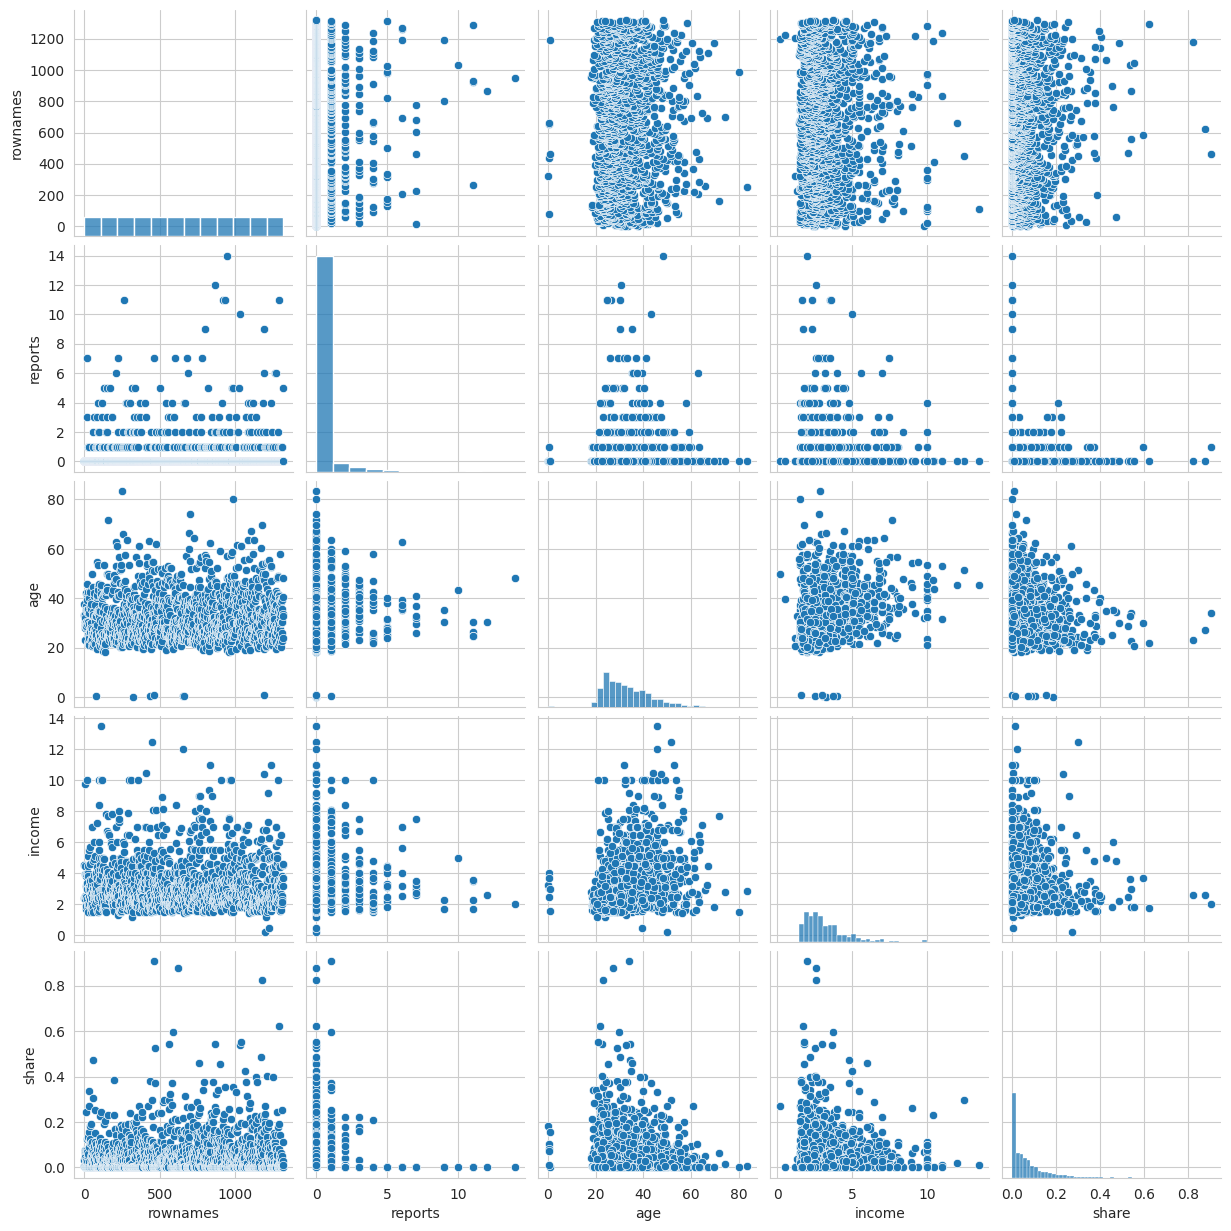

In [ ]:
# 2. Pairplot (using a categorical hue if available)
hue_var = cat_cols[0] if len(cat_cols) > 0 else None
try:
    sns.pairplot(df.select_dtypes(include=np.number).iloc[:, :5]) # taking first few numeric columns to avoid heavy rendering
    plt.show()
except Exception as e:
    print("Pairplot skipped or limited due to data dimensions:", e)